***

## Deep Learning & Generative AI - Exam Practice

## PRACTICAL 6 : RNN & LSTM for Time Series Forecast

***

#### Objective: To implement **Simple RNN and LSTM models** for time-series forecasting and compare their prediction performance on monthly airline passenger data.

#### Theory Notes:

* **RNN (Recurrent Neural Network):** A neural network designed for sequential data. It uses information from previous time steps to make predictions.
* **LSTM (Long Short-Term Memory):** A type of RNN that uses gates and a cell state to learn long-term dependencies more effectively.
* **Lookback:** Number of previous time steps used to predict the next value. Here, the lookback is **12 months**.
* **Min-Max Scaling:** Converts values into a small numerical range, helping neural networks train more effectively.
* **Time-series split:** Data must be split chronologically so future information is not used to train the model.
* **MSE:** Mean Squared Error, used as the training loss for forecasting.
* **MAE:** Mean Absolute Error; lower values indicate better predictions.
* **RMSE:** Square root of MSE; measures prediction error in the original scale.
* **MAPE:** Mean Absolute Percentage Error; expresses prediction error as a percentage.
* **Main difference:** LSTM generally handles long-term dependencies better than a basic RNN because of its memory mechanism.

***

### 1] import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

### 2] load the airline passenger data

In [3]:
# if the CSV is in the same folder as your Jupyter Notebook

# import pandas as pd
# df = pd.read_csv("airline-passengers.csv")
# print(df.head())

# if dataset is given through url link
# Load the monthly airline passenger dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'

try:
    df = pd.read_csv(url)
    df['Month'] = pd.to_datetime(df['Month'])
except:
    # Fallback data if the internet is unavailable
    passengers = [
        112,118,132,129,121,135,148,148,136,119,104,118,
        115,126,141,135,125,149,170,170,158,133,114,140,
        145,150,178,163,172,178,199,199,184,162,146,166,
        171,180,193,181,183,218,230,242,209,191,172,194,
        196,196,236,235,229,243,264,272,237,211,180,201,
        204,188,235,227,234,264,302,293,259,229,203,229,
        242,233,267,269,270,315,364,347,312,274,237,278,
        284,277,317,313,318,374,413,405,355,306,271,306,
        315,301,356,348,355,422,465,467,404,347,305,336,
        340,318,362,348,363,435,491,505,404,359,310,337,
        360,342,406,396,420,472,548,559,463,407,362,405,
        417,391,419,461,472,535,622,606,508,461,390,432
    ]
    df = pd.DataFrame({'Month': pd.date_range('1949-01-01', periods=len(passengers), freq='MS'),
                       'Passengers': passengers })

print(df.head())
print('Shape:', df.shape)

       Month  Passengers
0 1949-01-01         112
1 1949-02-01         118
2 1949-03-01         132
3 1949-04-01         129
4 1949-05-01         121
Shape: (144, 2)


### 3] visualize the time series

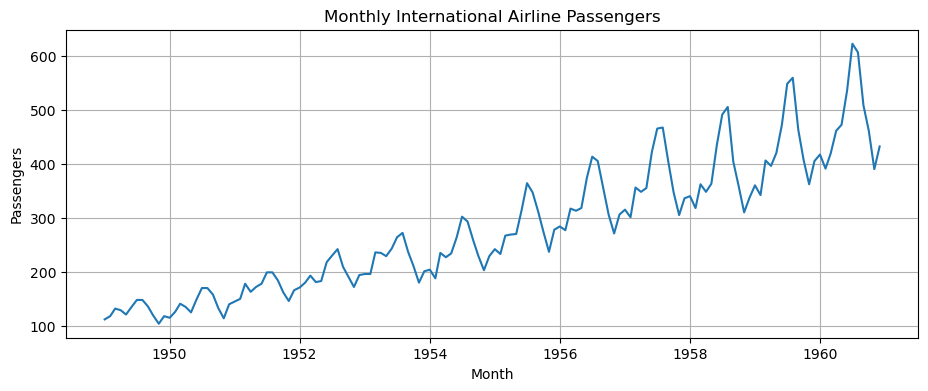

In [4]:
plt.figure(figsize=(11, 4))
plt.plot(df['Month'], df['Passengers'])
plt.title('Monthly International Airline Passengers')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.grid()
plt.show()

### 4] prepare the time series

An **80:20 chronological split** is used. The scaler is fitted only on the training portion to avoid future-data leakage.

A **12-month lookback** is used to predict the next month's passenger count.

In [5]:
LOOKBACK = 12
values = df['Passengers'].values.reshape(-1, 1).astype('float32')

train_size = int(len(values) * 0.8)

# Scale using training data only
scaler = MinMaxScaler()
scaler.fit(values[:train_size])
scaled = scaler.transform(values)

def make_sequences(data, start, end, lookback):
    X, y, indices = [], [], []
    for i in range(start, end):
        X.append(data[i-lookback:i])
        y.append(data[i])
        indices.append(i)
    return np.array(X), np.array(y), np.array(indices)

x_train, y_train, _ = make_sequences(scaled, LOOKBACK, train_size, LOOKBACK)
x_test, y_test, test_idx = make_sequences(scaled, train_size, len(scaled), LOOKBACK)

print('Training shape:', x_train.shape)
print('Testing shape:', x_test.shape)

Training shape: (103, 12, 1)
Testing shape: (29, 12, 1)


### 5] build the RNN

The RNN uses the previous 12 months as a sequence and predicts the next month's passenger count.

In [6]:
rnn = Sequential([Input(shape=(LOOKBACK, 1)),
                  SimpleRNN(32, activation='tanh'),
                  Dense(1) ])

rnn.compile(optimizer='adam', loss='mse')
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 32)                  │           1,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

### 6] build the LSTM

In [7]:
lstm = Sequential([Input(shape=(LOOKBACK, 1)),
                   LSTM(32),
                   Dense(1) ])

lstm.compile(optimizer='adam', loss='mse')
lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

### 7] train both models

In [8]:
early_stop = EarlyStopping( monitor='val_loss', patience=10, restore_best_weights=True )

rnn_history = rnn.fit(x_train, y_train, 
                      epochs=100, batch_size=8, 
                      validation_split=0.15, shuffle=False, 
                      callbacks=[early_stop], verbose=0 )

lstm_history = lstm.fit(x_train, y_train, 
                        epochs=100, batch_size=8, 
                        validation_split=0.15, shuffle=False, 
                        callbacks=[early_stop],verbose=0 )

print('RNN training completed.')
print('LSTM training completed.')

RNN training completed.
LSTM training completed.


### 8] compare validation loss

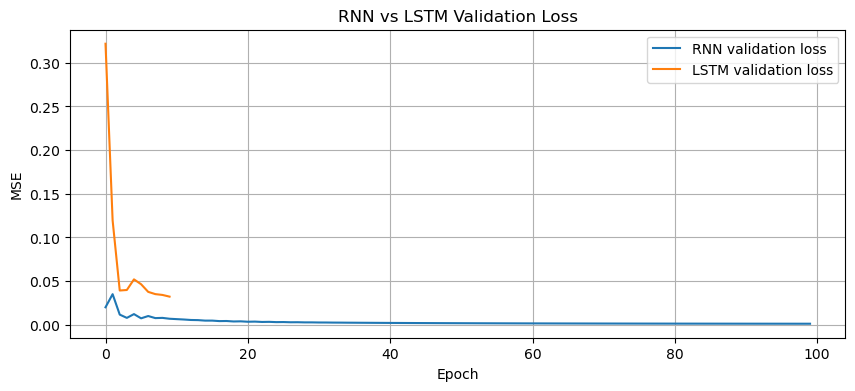

In [9]:
plt.figure(figsize=(10, 4))

plt.plot(rnn_history.history['val_loss'], label='RNN validation loss')
plt.plot(lstm_history.history['val_loss'], label='LSTM validation loss')

plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('RNN vs LSTM Validation Loss')
plt.legend()
plt.grid()
plt.show()

### 9] make test predictions

In [10]:
rnn_pred = scaler.inverse_transform( rnn.predict(x_test, verbose=0)).flatten()

lstm_pred = scaler.inverse_transform(lstm.predict(x_test, verbose=0)).flatten()

actual = scaler.inverse_transform(y_test).flatten()

print('Predictions generated.')

Predictions generated.


### 10] evaluate both models

Lower MAE, RMSE and MAPE indicate better forecasting performance.

In [11]:
def calculate_metrics(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return mae, rmse, mape

rnn_metrics = calculate_metrics(actual, rnn_pred)
lstm_metrics = calculate_metrics(actual, lstm_pred)

results = pd.DataFrame({ 'Metric': ['MAE', 'RMSE', 'MAPE (%)'],
                        'RNN': rnn_metrics,
                        'LSTM': lstm_metrics })

display(results)

,Metric,RNN,LSTM
0,MAE,27.076483,262.254089
1,RMSE,34.020351,274.033771
2,MAPE (%),5.817865,58.298600


### 11] plot actual vs predicted values

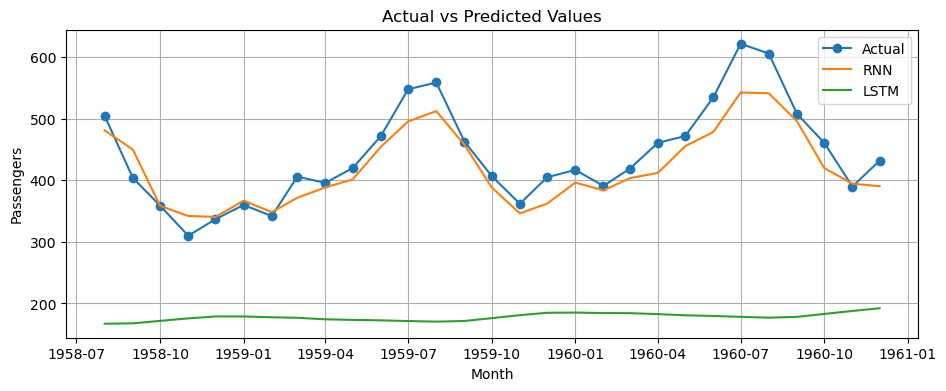

In [12]:
dates = df['Month'].iloc[test_idx]

plt.figure(figsize=(11, 4))
plt.plot(dates, actual, label='Actual', marker='o')
plt.plot(dates, rnn_pred, label='RNN')
plt.plot(dates, lstm_pred, label='LSTM')

plt.title('Actual vs Predicted Values')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid()
plt.show()

### 12] forecast the next 12 months

The model predicts one month at a time. Each prediction is added to the input window before predicting the next month.

In [13]:
def future_forecast(model, data, steps=12):
    window = data[-LOOKBACK:].copy()
    output = []

    for _ in range(steps):
        x = window.reshape(1, LOOKBACK, 1)
        pred = model.predict(x, verbose=0)[0, 0]
        output.append(pred)
        window = np.vstack((window[1:], [[pred]]))

    return scaler.inverse_transform(np.array(output).reshape(-1, 1)).flatten()

STEPS = 12
rnn_future = future_forecast(rnn, scaled, STEPS)
lstm_future = future_forecast(lstm, scaled, STEPS)

future_dates = pd.date_range( df['Month'].iloc[-1] + pd.offsets.MonthBegin(1), 
                             periods=STEPS, freq='MS')

future = pd.DataFrame({ 'Month': future_dates,
                       'RNN Forecast': rnn_future,
                       'LSTM Forecast': lstm_future })

display(future)

,Month,RNN Forecast,LSTM Forecast
0,1961-01-01,435.000244,192.609131
1,1961-02-01,394.148682,197.146469
2,1961-03-01,412.175415,195.880554
3,1961-04-01,431.135376,190.822372
4,1961-05-01,459.683777,184.000336
5,1961-06-01,502.329346,176.804062
6,1961-07-01,548.655090,169.576294
7,1961-08-01,534.768433,162.625320
8,1961-09-01,500.011993,156.766724
9,1961-10-01,456.419067,152.343369


### 13] plot the next 12-month forecast

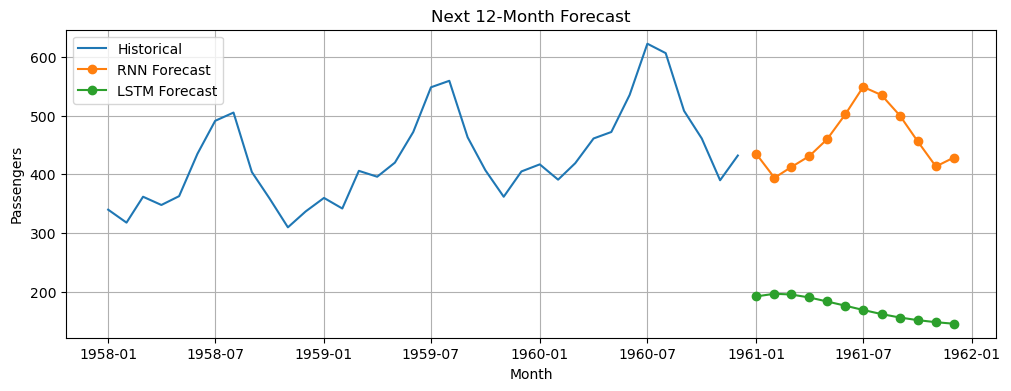

In [14]:
plt.figure(figsize=(12, 4))

plt.plot( df['Month'].iloc[-36:],
         df['Passengers'].iloc[-36:],
         label='Historical')

plt.plot(future['Month'], future['RNN Forecast'],
         marker='o', label='RNN Forecast' )

plt.plot(future['Month'], future['LSTM Forecast'],
         marker='o', label='LSTM Forecast')

plt.title('Next 12-Month Forecast')
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.legend()
plt.grid()
plt.show()

***

### quick revision:

* **RNN:** Processes sequential data using information from previous time steps.
* **LSTM:** RNN architecture designed to learn long-term dependencies.
* **Lookback:** 12 months in this practical.
* **Input shape:** `(12, 1)` — 12 previous values and 1 feature.
* **Activation:** `tanh` in the SimpleRNN.
* **Optimizer:** Adam.
* **Loss:** MSE.
* **MAE:** Average absolute prediction error.
* **RMSE:** Square root of MSE.
* **MAPE:** Percentage-based prediction error.
* **Forecasting:** Predictions are generated recursively for the next 12 months.
* **RNN vs LSTM:** LSTM generally handles long-term dependencies better because of its memory and gating mechanism.

***